<a href="https://colab.research.google.com/github/mathprofcarrie/DCS-F26-EvAlg/blob/main/Classic_Optimization_methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimization Methods: Finding the Peak of a Pumpkin's Flight

In this notebook, we will explore three numerical methods to find the maximum (optimum) of a function.

**The Scenario:** A pumpkin is shot from a cannon. Its height in meters, $f(x)$, at a horizontal distance $x$ is given by:
$$f(x) = 4 - (x - 2)^2$$

Our goal is to find the value of $x$ where the pumpkin reaches its maximum height. (Spoiler: Calculus tells us the answer is $x=2$, but let's see how computers find it!)

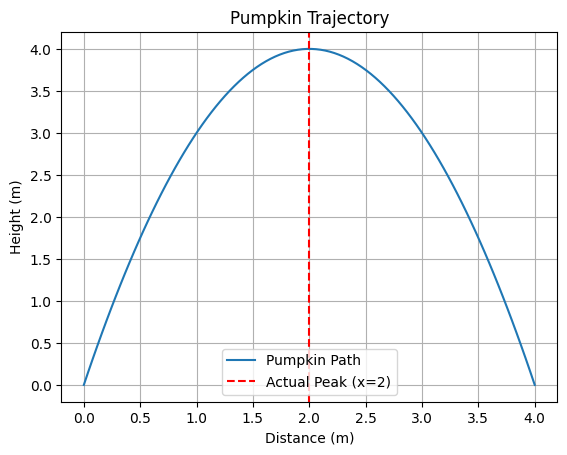

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define our pumpkin function
def f(x):
    return 4 - (x - 2)**2

# Define the derivative (needed for Newton and Gradient Descent)
# f'(x) = -2(x - 2)
def df(x):
    return -2 * (x - 2)

# Define the second derivative (needed for Newton's Method)
# f''(x) = -2
def ddf(x):
    return -2

# Let's visualize the pumpkin's flight first!
x_vals = np.linspace(0, 4, 100)
plt.plot(x_vals, f(x_vals), label='Pumpkin Path')
plt.axvline(2, color='red', linestyle='--', label='Actual Peak (x=2)')
plt.title("Pumpkin Trajectory")
plt.xlabel("Distance (m)")
plt.ylabel("Height (m)")
plt.legend()
plt.grid(True)
plt.show()

## 0. The "Guess and Check" Method

Before we dive into automated algorithms, the simplest way to find an optimum is to just try a few values! This is often called a **Brute Force** search or a manual grid search.

Let's try a few horizontal distances ($x$) and see which one gives us the highest pumpkin height.

In [5]:
# A list of horizontal distances we want to test
guesses = [0.0, 1.0, 2.0, 3.0, 4.0]

# A list (vector) to store our results
heights = []

print("Manual Guessing Results:")
print("-----------------------")

for x_guess in guesses:
    height = f(x_guess)
    heights.append(height)
    print(f"At x = {x_guess}m, the pumpkin height is {height}m")

# Use the max function to find the highest value in our vector
max_height = max(heights)
print(f"\nThe maximum height we found by guessing was: {max_height}m")

# Encouragement for students:
# We stored all heights in the 'heights' list.
# This allows us to use functions like max() to search through our data!

Manual Guessing Results:
-----------------------
At x = 0.0m, the pumpkin height is 0.0m
At x = 1.0m, the pumpkin height is 3.0m
At x = 2.0m, the pumpkin height is 4.0m
At x = 3.0m, the pumpkin height is 3.0m
At x = 4.0m, the pumpkin height is 0.0m


## 1. Gradient Descent (Ascent)
Gradient descent moves step-by-step in the direction of the slope. Since we want the *maximum*, we technically perform 'Gradient Ascent' by adding the gradient.

In [3]:
def gradient_ascent(start_x, learning_rate=0.1, steps=20):
    x = start_x
    history = [x]

    for i in range(steps):
        # Move x in the direction of the positive slope
        x = x + learning_rate * df(x)
        history.append(x)
        if i % 5 == 0: # Print every 5 steps
            print(f"Step {i}: x = {x:.4f}")

    return x, history

# Try it out! You can change the learning_rate to see how it affects speed.
peak_grad, path = gradient_ascent(start_x=0.1, learning_rate=0.2)
print(f"\nGradient Ascent found peak at: {peak_grad:.4f}")

Step 0: x = 0.8600
Step 5: x = 1.9114
Step 10: x = 1.9931
Step 15: x = 1.9995

Gradient Ascent found peak at: 1.9999


## 3. Bisection Method
The bisection method is a 'brute force' approach. It doesn't use derivatives. It looks for a root (where $f'(x)=0$) by repeatedly cutting an interval in half.

In [4]:
def bisection_method(a, b, tolerance=0.01):
    # We look for where the derivative df(x) is 0
    if df(a) * df(b) > 0:
        print("The peak might not be between these points!")
        return None

    while (b - a) / 2 > tolerance:
        midpoint = (a + b) / 2
        if df(midpoint) == 0:
            return midpoint
        elif df(a) * df(midpoint) < 0:
            b = midpoint # The peak is in the left half
        else:
            a = midpoint # The peak is in the right half

    return (a + b) / 2

# Try it out with a range from 0 to 5
peak_bisect = bisection_method(0, 5)
print(f"Bisection Method found peak near: {peak_bisect:.4f}")

Bisection Method found peak near: 2.0020


## 3. Newton's Method
Newton's method uses calculus (derivatives) to find where the slope is zero. It is very fast but requires knowing the second derivative.

In [2]:
def newtons_method(start_x, iterations=5):
    x = start_x
    print(f"Starting Newton's Method at x = {x}")

    for i in range(iterations):
        # Newton's update rule for optimization: x = x - f'(x) / f''(x)
        x = x - df(x) / ddf(x)
        print(f"Iteration {i+1}: x = {x:.4f}, f(x) = {f(x):.4f}")

    return x

# Try it out!
peak_newton = newtons_method(start_x=0.5)
print(f"\nNewton found the peak at: {peak_newton} meters.")

Starting Newton's Method at x = 0.5
Iteration 1: x = 2.0000, f(x) = 4.0000
Iteration 2: x = 2.0000, f(x) = 4.0000
Iteration 3: x = 2.0000, f(x) = 4.0000
Iteration 4: x = 2.0000, f(x) = 4.0000
Iteration 5: x = 2.0000, f(x) = 4.0000

Newton found the peak at: 2.0 meters.


## Summary and Challenge
1. **Newton's Method** was the fastest for this specific function.
2. **Gradient Ascent** is the most common in Machine Learning.
3. **Bisection** is the most reliable if you don't know the derivative.

**Try it yourself:** Can you change the pumpkin function to $f(x) = 10 - (x - 5)^2$ and update the derivatives to find the new peak?